## Sztuczne sieci neuronowe - pereptron


Do zadania regresji wykorzystano zbiór danych load_diabetes z biblioteki sklearn. 
Dla zadania klasyfikacji wygenerowano sztuczny zbiór danych za pomocą funkcji make_classification o rozmiarze 1000 próbek i o 20 cecach wejściowych.

W zadaniu regresji (MLPRegressor z jedną warstwą ukrytą 100 neuronów, aktywacja ReLU, solver Adam) uzyskano MSE ≈ 3622 oraz R2 ≈ 0.39 na zbiorze testowym.
Oznacza to, że sieć wyjaśnia ok. 39% wariancji zmiennej co moze wynikać ze stosunkowo małego zbioru danych. 

W zadaniu MLPClassifier z jedną warstwą 100 neuronów model uzyskał wynik poprawnej klasyfikacji 83.5%. 

Analiza wpływu liczby neuronów w pojedynczej warstwie ukrytej pokazuje, że zbyt mała liczba neuronów prowadzi do silnego niedouczenia.
Dla 10 neuronów MSE 17210, a R2 −1.91, co oznacza, że sieć radzi sobie gorzej niż prosta średnia z danych.
Zwiększenie liczby neuronów do 50 wyraźnie poprawia jakość, ale dopiero przy 100 neuronach model osiąga R² ≈ 0.39, a przy 200 neuronach – około 0.43.
Wzrost liczby neuronów do 200 daje zauważalny, ale już mniejszy przyrost jakości względem 100 neuronów.

Dla liczby warstw mozna zauwazyć poprawę wyników dla kolejno 1->2->3 warstw. W momencie wykorzystania 4 warstwy jakość zaczyna spadać, co moze sugerować przeuczenie. 

Dla funkcji aktywacji najlepsze wyniki otrzymano po zastosowaniu ReLU. Tanh i logistic uzyskały gorsze wyniki, moze to wynikać z charaktersytyki, są to funkcję saturujące, co przekłada się na pojawianie się problemu zanikającego gradientu. ReLU jest nieliniowe. 

Parametr alpha ma za zadanie zapobieganie przeuczeniu się. Wykorzystany dataset posiada znormalizowane dane, co więcej wykorzystany został solver Adam, który charakteryzuje się wysoką stabilnością. Te aspekty mogły wpłynąć na to, ze kolejne iteracje zmiany parametru alpha dawały identyczne lub zblizone efekty. 




In [ ]:

from sklearn.datasets import load_diabetes, make_classification
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')

diabetes = load_diabetes()
diabetes_info = diabetes['DESCR']
diabetes_names = diabetes['feature_names']
print(diabetes_info, "\n\nNazwy cech:", diabetes_names)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [17]:
X_reg = diabetes.data
y_reg = diabetes.target

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=17
)

print("Regresja:\nX_reg shape:", X_reg.shape, "y_reg shape:", y_reg.shape)

Regresja:
X_reg shape: (442, 10) y_reg shape: (442,)


In [18]:
X_clf, y_clf = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    random_state=17
)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=17
)
print("Klasyfikacja:\nX_clf shape:", X_clf.shape, "y_clf shape:", y_clf.shape)

Klasyfikacja:
X_clf shape: (1000, 20) y_clf shape: (1000,)


In [19]:
model_reg = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=17
)
model_reg.fit(X_reg_train, y_reg_train)
y_reg_pred = model_reg.predict(X_reg_test)

mse_reg = mean_squared_error(y_reg_test, y_reg_pred)
r2_reg = r2_score(y_reg_test, y_reg_pred)
print(f"Regresja:\nPodstawowy model: MSE = {mse_reg:.2f}, R^2 = {r2_reg:.2f}")

Regresja:
Podstawowy model: MSE = 3622.37, R^2 = 0.39


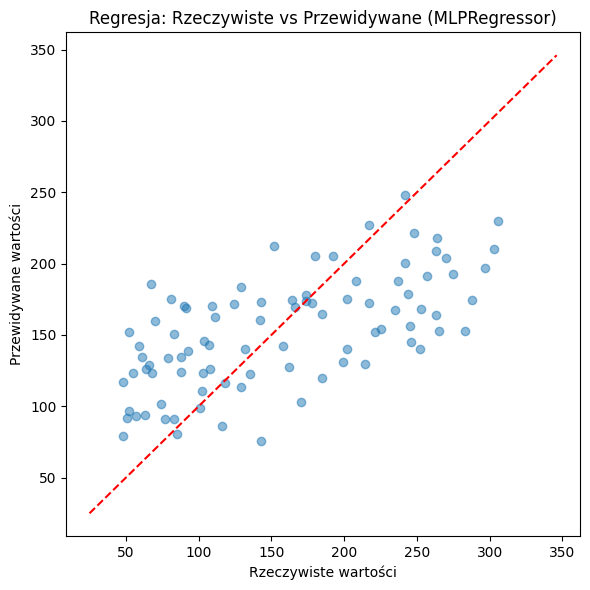

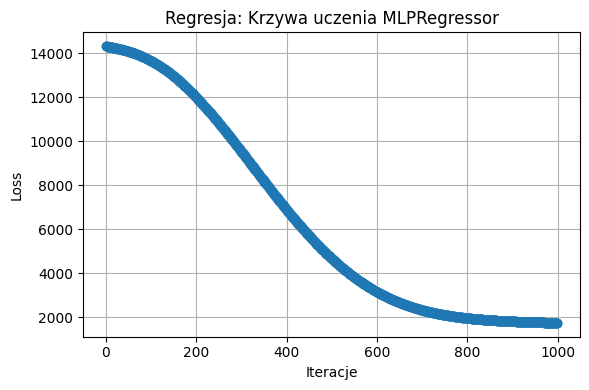

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--')
plt.xlabel('Rzeczywiste wartości')
plt.ylabel('Przewidywane wartości')
plt.title('Regresja: Rzeczywiste vs Przewidywane (MLPRegressor)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(model_reg.loss_curve_, marker='o')
plt.title('Regresja: Krzywa uczenia MLPRegressor')
plt.xlabel('Iteracje')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
model_clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=17
)
model_clf.fit(X_clf_train, y_clf_train)
y_clf_pred = model_clf.predict(X_clf_test)

acc_clf = accuracy_score(y_clf_test, y_clf_pred)
print(f"Klasyfikacja:\nPodstawowy model: accuracy = {acc_clf:.3f}")

Klasyfikacja:
Podstawowy model: accuracy = 0.990


In [21]:
print("Wpływ liczby neuronów na regresje:")

for neurons in [10, 50, 100, 200]:
    model = MLPRegressor(
        hidden_layer_sizes=(neurons,),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=17
    )
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_pred)
    r2 = r2_score(y_reg_test, y_pred)
    print(f'Neurony: {neurons:3d}, MSE: {mse:.2f}, R^2: {r2:.2f}')

Wpływ liczby neuronów na regresje:
Neurony:  10, MSE: 17210.20, R^2: -1.91
Neurony:  50, MSE: 4947.34, R^2: 0.16
Neurony: 100, MSE: 3622.37, R^2: 0.39
Neurony: 200, MSE: 3357.64, R^2: 0.43


In [22]:
print("Wpływ liczby warstw na regresje:")

for layers in [(50, 50), (50, 50, 50), (50, 50, 50, 50)]:
    model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=17
    )
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_pred)
    r2 = r2_score(y_reg_test, y_pred)
    print(f'Warstwy: {layers}, MSE: {mse:.2f}, R^2: {r2:.2f}')

Wpływ liczby warstw na regresje:
Warstwy: (50, 50), MSE: 3322.52, R^2: 0.44
Warstwy: (50, 50, 50), MSE: 3266.67, R^2: 0.45
Warstwy: (50, 50, 50, 50), MSE: 3332.79, R^2: 0.44


In [23]:
print("Wpływ funkcji aktywacji na regresje:")

for activation in ['relu', 'tanh', 'logistic']:
    model = MLPRegressor(
        hidden_layer_sizes=(100,),
        activation=activation,
        solver='adam',
        max_iter=1000,
        random_state=17
    )
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_pred)
    r2 = r2_score(y_reg_test, y_pred)
    print(f'Aktywacja: {activation:8s}, MSE: {mse:.2f}, R^2: {r2:.2f}')

Wpływ funkcji aktywacji na regresje:
Aktywacja: relu    , MSE: 3622.37, R^2: 0.39
Aktywacja: tanh    , MSE: 4533.12, R^2: 0.23
Aktywacja: logistic, MSE: 5561.85, R^2: 0.06


In [24]:
print("Wpływ parametru alpha na regresje:")

for alpha in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    model = MLPRegressor(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        alpha=alpha,
        max_iter=1000,
        random_state=17
    )
    model.fit(X_reg_train, y_reg_train)
    y_pred = model.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_pred)
    r2 = r2_score(y_reg_test, y_pred)
    print(f'Alpha: {alpha:7.4f}, MSE: {mse:.2f}, R^2: {r2:.2f}')

Wpływ parametru alpha na regresje:
Alpha:  0.0001, MSE: 3622.37, R^2: 0.39
Alpha:  0.0010, MSE: 3622.37, R^2: 0.39
Alpha:  0.0100, MSE: 3622.37, R^2: 0.39
Alpha:  0.1000, MSE: 3622.35, R^2: 0.39
Alpha:  1.0000, MSE: 3622.05, R^2: 0.39


In [ ]:
import numpy as np

class MLP:
    def __init__(self, input_size, hidden_sizes, output_size):
        self.weights_input_hidden = np.random.rand(input_size, hidden_sizes)
        self.weights_hidden_output = np.random.rand(hidden_sizes, output_size)
        self.bias_hidden = np.zeros((1, hidden_sizes))
        self.bias_output = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, X):
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = self.relu(self.hidden_input)
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        return self.final_input   
    
    def backward(self, X, y, output, learning_rate):
        n = X.shape[0]
        output_error = (output - y) / n
        hidden_output_error = np.dot(output_error, self.weights_hidden_output.T) * self.relu_derivative(self.hidden_input)
        self.weights_hidden_output -= learning_rate * np.dot(self.hidden_output.T, output_error)
        self.bias_output -= learning_rate * np.sum(output_error, axis=0, keepdims=True)
        self.weights_input_hidden -= learning_rate * np.dot(X.T, hidden_output_error)
        self.bias_hidden -= learning_rate * np.sum(hidden_output_error, axis=0, keepdims=True)

    def train(self, X, y, epochs, learning_rate):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output, learning_rate)

            if (epoch + 1) % 100 == 0:
                loss = np.mean((y - output) ** 2)
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}')
    
    def predict(self, X):
        return self.forward(X)


In [29]:
mlp = MLP(input_size=10, hidden_sizes=10, output_size=1)
y_reg_train_col = y_reg_train.reshape(-1, 1)
mlp.train(X_reg_train, y_reg_train_col, epochs=1000, learning_rate=1e-4)
y_reg_pred_mlp = mlp.forward(X_reg_test)
mse_mlp = mean_squared_error(y_reg_test, y_reg_pred_mlp)


print(f"MLPRegressor (sklearn): MSE = {mse_reg:.2f}")
print(f"Własny MLP: MSE = {mse_mlp:.2f}")

Epoch 100/1000, Loss: 23664.4071
Epoch 200/1000, Loss: 7473.6676
Epoch 300/1000, Loss: 5537.2809
Epoch 400/1000, Loss: 5478.1944
Epoch 500/1000, Loss: 5427.4051
Epoch 600/1000, Loss: 5376.5290
Epoch 700/1000, Loss: 5325.4646
Epoch 800/1000, Loss: 5274.1397
Epoch 900/1000, Loss: 5222.4928
Epoch 1000/1000, Loss: 5170.4733
MLPRegressor (sklearn): MSE = 3622.37
Własny MLP: MSE = 5120.17


## Własna implementacja vs Sklearn

Wyniki oparte na własej implementacji perceptronu wielowarstwowego osiągneły wyraźnie gorsze wyniki, niz wersja z Sklearn. Spadająca strata od 100 do 300 z kazdym kolejnym treningiem gwałtownie spada co oznacza, ze sieć działa. Od epoki 300 do końca spadek dalej się pojawia ale jest znacznie wolniejszy. Model Sklearn poprzez lepszy wynik MSE oznacza lepsze dopasowanie do danych testowych. Własna implementacja pomimo gorszych wyników działa, ale jakość jej predykcji jest jakościowa.